In [13]:
"""Synthetic Proteomic Aging Clock

This project recreates the coding workflow of a proteomic biological aging clock using synthetic protein data.

The goal is to:
1. Use protein levels to predict age.
2. Calculate biological age gap.
3. Compare machine learning models.
4. Identify which proteins are most important.
5. Test what happens when important proteins are removed.
"""

'Synthetic Proteomic Aging Clock\n\nThis project recreates the coding workflow of a proteomic biological aging clock using synthetic protein data.\n\nThe goal is to:\n1. Use protein levels to predict age.\n2. Calculate biological age gap.\n3. Compare machine learning models.\n4. Identify which proteins are most important.\n5. Test what happens when important proteins are removed.\n'

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LassoCV
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [15]:
df = pd.read_csv("../data/synthetic_proteomic_aging_data.csv")

df.head()

,participant_id,age,sex,NEFL,GFAP,BDNF,IL6,TNF,CRP,GDF15,ALB,IGF1,NTproBNP,CST3,KIM1,VEGFA,APOE,MMP9,synthetic_high_aging_risk
0,P0001,78,Male,47.087040,44.760137,62.884652,16.009502,21.873137,30.884698,86.091544,83.140484,70.806817,67.230574,34.012579,22.856738,64.842463,69.431570,41.960774,0
1,P0002,68,Female,48.351198,46.291052,73.619844,25.570745,22.715175,23.240285,81.421332,110.478845,77.016301,63.013225,40.889864,12.694032,43.468540,82.674340,35.903480,1
2,P0003,54,Female,58.681492,33.714351,78.562020,8.733129,23.437053,26.188537,80.890317,101.015956,94.672177,15.719860,35.876762,15.435888,49.062692,78.949886,57.371510,0
3,P0004,47,Male,46.276743,25.276877,68.315915,17.178213,33.904551,7.638173,62.326109,94.519004,102.384472,27.386199,39.054842,18.590070,43.671640,66.566615,58.122080,0
4,P0005,60,Female,42.430568,34.858531,77.673411,32.860269,25.240181,23.075653,77.948934,109.223304,73.150128,48.949187,41.537980,16.496521,68.514657,75.863856,36.158909,1


In [16]:
df.shape

(1000, 19)

In [17]:
df.columns

Index(['participant_id', 'age', 'sex', 'NEFL', 'GFAP', 'BDNF', 'IL6', 'TNF',
       'CRP', 'GDF15', 'ALB', 'IGF1', 'NTproBNP', 'CST3', 'KIM1', 'VEGFA',
       'APOE', 'MMP9', 'synthetic_high_aging_risk'],
      dtype='str')

In [18]:
df.describe()

,age,NEFL,GFAP,BDNF,IL6,TNF,CRP,GDF15,ALB,IGF1,NTproBNP,CST3,KIM1,VEGFA,APOE,MMP9,synthetic_high_aging_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,60.338000,47.731206,36.168133,74.771756,22.773066,21.054722,19.706911,78.412387,96.025701,79.730882,42.715978,36.070503,17.104204,50.764608,73.489695,44.907657,0.300000
std,11.980872,9.806334,8.138170,8.717538,6.780424,5.742367,7.912845,13.916806,9.269945,11.469072,13.722042,8.354780,5.546714,12.337223,15.082866,10.240784,0.458487
min,40.000000,15.529196,8.563415,47.244094,0.100000,4.188610,0.100000,34.857511,62.106756,44.047004,0.100000,4.770946,1.508536,13.009254,23.444998,8.647998,0.000000
25%,50.000000,41.122070,30.708616,68.586667,18.312286,17.238609,13.873375,68.384097,89.531640,71.835001,33.932853,30.587730,13.264623,42.427570,63.327043,38.080747,0.000000
50%,61.000000,47.642334,35.952999,75.002507,22.669399,21.067393,19.346112,78.365238,96.117059,80.117604,42.530875,36.491337,16.996567,50.939463,73.056940,44.924501,0.000000
75%,71.000000,54.507265,41.890988,80.504861,27.396987,24.685032,25.046488,88.582964,102.232953,87.576526,51.528817,41.638742,20.904507,58.915450,83.620827,51.872220,1.000000
max,80.000000,74.801988,61.796813,101.944744,45.061162,39.576350,47.023386,118.630483,123.542485,114.803697,84.866476,62.214328,35.220591,91.146926,120.106344,89.790843,1.000000


In [19]:
X = df.drop(columns=[
    "participant_id",
    "age",
    "sex",
    "synthetic_high_aging_risk"
])

y = df["age"]

X.head()

,NEFL,GFAP,BDNF,IL6,TNF,CRP,GDF15,ALB,IGF1,NTproBNP,CST3,KIM1,VEGFA,APOE,MMP9
0,47.087040,44.760137,62.884652,16.009502,21.873137,30.884698,86.091544,83.140484,70.806817,67.230574,34.012579,22.856738,64.842463,69.431570,41.960774
1,48.351198,46.291052,73.619844,25.570745,22.715175,23.240285,81.421332,110.478845,77.016301,63.013225,40.889864,12.694032,43.468540,82.674340,35.903480
2,58.681492,33.714351,78.562020,8.733129,23.437053,26.188537,80.890317,101.015956,94.672177,15.719860,35.876762,15.435888,49.062692,78.949886,57.371510
3,46.276743,25.276877,68.315915,17.178213,33.904551,7.638173,62.326109,94.519004,102.384472,27.386199,39.054842,18.590070,43.671640,66.566615,58.122080
4,42.430568,34.858531,77.673411,32.860269,25.240181,23.075653,77.948934,109.223304,73.150128,48.949187,41.537980,16.496521,68.514657,75.863856,36.158909


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((800, 15), (200, 15))

In [21]:
lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42)
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("LASSO MAE:", lasso_mae)
print("LASSO R2:", lasso_r2)

LASSO MAE: 4.24970653495691
LASSO R2: 0.7947560993949235


In [22]:
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf")
)

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)

svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("SVR MAE:", svr_mae)
print("SVR R2:", svr_r2)

SVR MAE: 4.315219646892857
SVR R2: 0.7851197127175555


In [23]:
nn_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32, 16),
        max_iter=1000,
        random_state=42
    )
)

nn_model.fit(X_train, y_train)

nn_pred = nn_model.predict(X_test)

nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)

print("Neural Network MAE:", nn_mae)
print("Neural Network R2:", nn_r2)

Neural Network MAE: 4.730821924405411
Neural Network R2: 0.7290098458948678


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [24]:
comparison = pd.DataFrame({
    "Model": ["LASSO", "SVR", "Neural Network"],
    "MAE": [lasso_mae, svr_mae, nn_mae],
    "R2": [lasso_r2, svr_r2, nn_r2]
})

comparison

,Model,MAE,R2
0,LASSO,4.249707,0.794756
1,SVR,4.315220,0.785120
2,Neural Network,4.730822,0.729010


In [25]:
results = pd.DataFrame({
    "real_age": y_test,
    "predicted_age": lasso_pred
})

results["biological_age_gap"] = results["predicted_age"] - results["real_age"]

results.head()

,real_age,predicted_age,biological_age_gap
521,55,58.956280,3.956280
737,43,52.277862,9.277862
740,64,64.564919,0.564919
660,44,41.686068,-2.313932
411,65,76.320329,11.320329


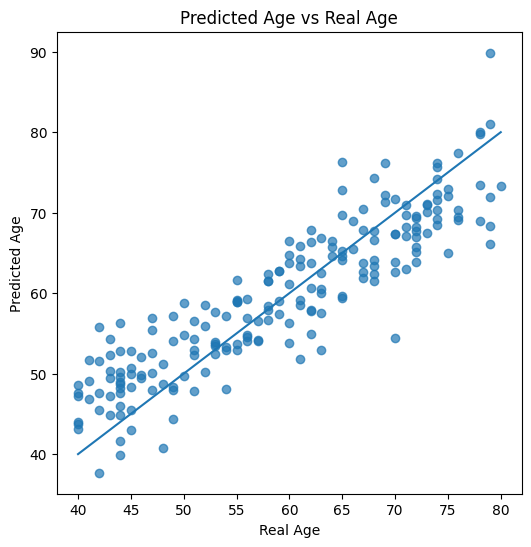

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(results["real_age"], results["predicted_age"], alpha=0.7)
plt.plot(
    [results["real_age"].min(), results["real_age"].max()],
    [results["real_age"].min(), results["real_age"].max()]
)
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted Age vs Real Age")
plt.show()

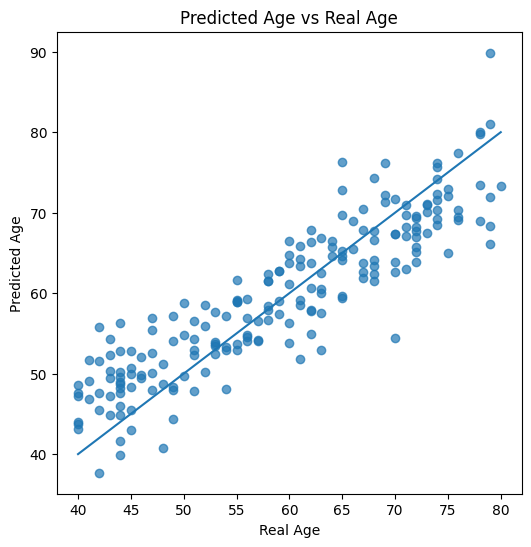

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(results["real_age"], results["predicted_age"], alpha=0.7)
plt.plot(
    [results["real_age"].min(), results["real_age"].max()],
    [results["real_age"].min(), results["real_age"].max()]
)
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted Age vs Real Age")
plt.show()

In [28]:
lasso = lasso_model.named_steps["lassocv"]

importance = pd.DataFrame({
    "protein": X.columns,
    "coefficient": lasso.coef_
})

importance["absolute_importance"] = importance["coefficient"].abs()

importance = importance.sort_values(
    "absolute_importance",
    ascending=False
)

importance

,protein,coefficient,absolute_importance
6,GDF15,2.374370,2.374370
0,NEFL,1.877590,1.877590
10,CST3,1.828551,1.828551
7,ALB,-1.740079,1.740079
9,NTproBNP,1.671737,1.671737
1,GFAP,1.634973,1.634973
8,IGF1,-1.527766,1.527766
3,IL6,1.333979,1.333979
11,KIM1,1.261986,1.261986
5,CRP,1.151296,1.151296


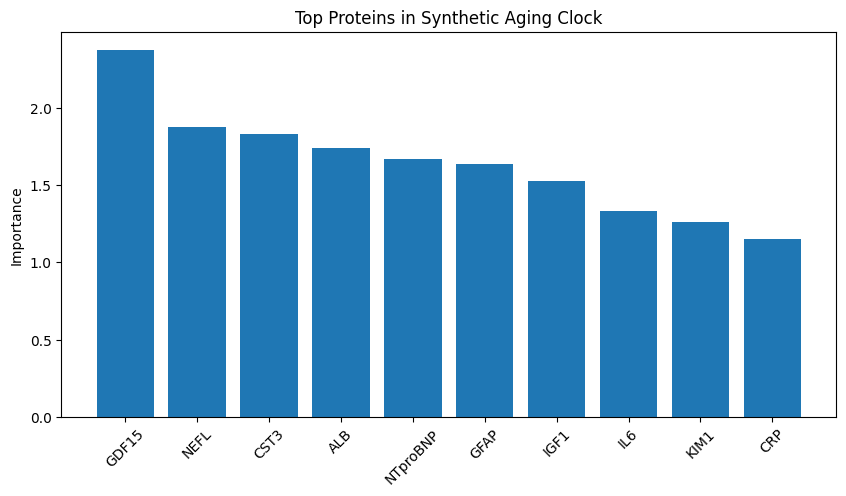

In [29]:
top_proteins = importance.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_proteins["protein"], top_proteins["absolute_importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Top Proteins in Synthetic Aging Clock")
plt.show()

In [30]:
top_protein = importance.iloc[0]["protein"]

print("Top protein:", top_protein)

X_removed = X.drop(columns=[top_protein])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_removed,
    y,
    test_size=0.2,
    random_state=42
)

removed_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42)
)

removed_model.fit(X_train_r, y_train_r)

removed_pred = removed_model.predict(X_test_r)

removed_mae = mean_absolute_error(y_test_r, removed_pred)

print("Original LASSO MAE:", lasso_mae)
print("MAE after removing", top_protein, ":", removed_mae)

Top protein: GDF15
Original LASSO MAE: 4.24970653495691
MAE after removing GDF15 : 4.6927161179750705
